In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi

In [2]:
api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    'rohanrao/formula-1-world-championship-1950-2020',
    path='./f1_datasets',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020


In [3]:
import pandas as pd
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

datasets = ['circuits', 'constructors', 'drivers', 'races', 'results']

dataframes = {}
for dataset in datasets:
    file_path = os.path.join('./f1_datasets', f'{dataset}.csv')
    dataframes[dataset] = pd.read_csv(file_path)

dataframes

{'circuits':     circuitId   circuitRef                                  name  \
 0           1  albert_park        Albert Park Grand Prix Circuit   
 1           2       sepang          Sepang International Circuit   
 2           3      bahrain         Bahrain International Circuit   
 3           4    catalunya        Circuit de Barcelona-Catalunya   
 4           5     istanbul                         Istanbul Park   
 ..        ...          ...                                   ...   
 72         75     portimao    Autódromo Internacional do Algarve   
 73         76      mugello  Autodromo Internazionale del Mugello   
 74         77       jeddah               Jeddah Corniche Circuit   
 75         78       losail          Losail International Circuit   
 76         79        miami         Miami International Autodrome   
 
         location       country       lat        lng  alt  \
 0      Melbourne     Australia -37.84970  144.96800   10   
 1   Kuala Lumpur      Malaysia   2.

In [4]:
dataframes['races'].columns, dataframes['results'].columns, dataframes['constructors'].columns, dataframes['circuits'].columns, dataframes['drivers'].columns

(Index(['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url',
        'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
        'quali_date', 'quali_time', 'sprint_date', 'sprint_time'],
       dtype='object'),
 Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
        'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
        'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
        'fastestLapSpeed', 'statusId'],
       dtype='object'),
 Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object'),
 Index(['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng',
        'alt', 'url'],
       dtype='object'),
 Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
        'nationality', 'url'],
       dtype='object'))

In [5]:
dataframes['races'].drop(columns=['url', 'round', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
        'quali_date', 'quali_time', 'sprint_date', 'sprint_time', 'time'], inplace=True)
dataframes['races'].rename(columns={'name': 'GP name'}, inplace=True)
dataframes['constructors'].drop(columns=['constructorRef', 'url'], inplace=True)
dataframes['constructors'].rename(columns={'name': 'team', 'nationality': 'team_home'}, inplace=True)
dataframes['drivers'].drop(columns=['forename', 'driverRef', 'code', 'number', 'url'], inplace=True)
dataframes['drivers'].rename(columns={'surname': 'driver', 'nationality': 'driver_home'}, inplace=True)
dataframes['results'].drop(columns=['positionText', 'points', 'laps', 'time', 'milliseconds', 'positionOrder', 'fastestLapTime',
                                    'fastestLapSpeed', 'rank', 'laps', 'time', 'number'], inplace=True)
dataframes['results'].rename(columns={'position': 'finish', 'grid': 'start'}, inplace=True)
dataframes['circuits'].drop(columns=['circuitRef', 'url', 'lat', 'lng', 'alt'], inplace=True)
dataframes['circuits'].rename(columns={'name': 'circuit name'}, inplace=True)

In [6]:
f1_data = dataframes['races'].merge(
    dataframes['results'], on='raceId', how='left'
    ).merge(
        dataframes['constructors'], on='constructorId', how='left'
    ).merge(
        dataframes['drivers'], on='driverId', how='left'
    ).merge(
        dataframes['circuits'], on='circuitId', how='left'
        )



In [7]:
f1_data = f1_data[f1_data['year'] >= 2018]
f1_data.shape

(2979, 20)

In [8]:
f1_data['date'] = pd.to_datetime(f1_data['date'])
f1_data['dob'] = pd.to_datetime(f1_data['dob'])

In [9]:
f1_data.columns

Index(['raceId', 'year', 'circuitId', 'GP name', 'date', 'resultId',
       'driverId', 'constructorId', 'start', 'finish', 'fastestLap',
       'statusId', 'team', 'team_home', 'driver', 'dob', 'driver_home',
       'circuit name', 'location', 'country'],
      dtype='object')

In [10]:
f1_data.drop(columns=['resultId', 'constructorId', 'fastestLap', 'driverId', 'circuitId', 'raceId'], inplace=True)
f1_data.shape

(2979, 14)

In [11]:
f1_data

,year,GP name,date,start,finish,statusId,team,team_home,driver,dob,driver_home,circuit name,location,country
23780,2018,Australian Grand Prix,2018-03-25,3,1,1,Ferrari,Italian,Vettel,1987-07-03,German,Albert Park Grand Prix Circuit,Melbourne,Australia
23781,2018,Australian Grand Prix,2018-03-25,1,2,1,Mercedes,German,Hamilton,1985-01-07,British,Albert Park Grand Prix Circuit,Melbourne,Australia
23782,2018,Australian Grand Prix,2018-03-25,2,3,1,Ferrari,Italian,Räikkönen,1979-10-17,Finnish,Albert Park Grand Prix Circuit,Melbourne,Australia
23783,2018,Australian Grand Prix,2018-03-25,8,4,1,Red Bull,Austrian,Ricciardo,1989-07-01,Australian,Albert Park Grand Prix Circuit,Melbourne,Australia
23784,2018,Australian Grand Prix,2018-03-25,10,5,1,McLaren,British,Alonso,1981-07-29,Spanish,Albert Park Grand Prix Circuit,Melbourne,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,2024,Abu Dhabi Grand Prix,2024-12-08,14,16,11,Haas F1 Team,American,Magnussen,1992-10-05,Danish,Yas Marina Circuit,Abu Dhabi,UAE
26755,2024,Abu Dhabi Grand Prix,2024-12-08,12,17,5,RB F1 Team,Italian,Lawson,2002-02-11,New Zealander,Yas Marina Circuit,Abu Dhabi,UAE
26756,2024,Abu Dhabi Grand Prix,2024-12-08,9,\N,130,Sauber,Swiss,Bottas,1989-08-28,Finnish,Yas Marina Circuit,Abu Dhabi,UAE
26757,2024,Abu Dhabi Grand Prix,2024-12-08,20,\N,5,Williams,British,Colapinto,2003-05-27,Argentinian,Yas Marina Circuit,Abu Dhabi,UAE


In [12]:
print(f1_data['team_home'].unique())
print(f1_data['driver_home'].unique())
print(f1_data['country'].unique())

['Italian' 'German' 'Austrian' 'British' 'French' 'Indian' 'Swiss'
 'American']
['German' 'British' 'Finnish' 'Australian' 'Spanish' 'Dutch' 'Belgian'
 'Mexican' 'French' 'Monegasque' 'Canadian' 'New Zealander' 'Danish'
 'Swedish' 'Russian' 'Thai' 'Italian' 'Polish' 'Brazilian' 'Japanese'
 'Chinese' 'American' 'Argentinian ']
['Australia' 'Bahrain' 'China' 'Azerbaijan' 'Spain' 'Monaco' 'Canada'
 'France' 'Austria' 'UK' 'Germany' 'Hungary' 'Belgium' 'Italy' 'Singapore'
 'Russia' 'Japan' 'USA' 'Mexico' 'Brazil' 'UAE' 'Portugal' 'Turkey'
 'Qatar' 'Netherlands' 'Saudi Arabia' 'United States']


In [13]:
def nationality(x):
    x = str(x).strip().lower()
    if x in ['austrian', 'austria']:
        return 'AUT'
    if x in ['australian', 'australia']:
        return 'AUS'
    if x in ['indian', 'india']:
        return 'IND'
    if x in ['indonesian', 'indonesia']:
        return 'INA'
    if x in ['uk', 'british', 'england', 'great britain']:
        return 'BRI'
    if x in ['usa', 'united states', 'american']:
        return 'AME'
    if x in ['fra', 'france', 'french']:
        return 'FRE'
    return x[:3].upper()

f1_data['driver_home'] = f1_data['driver_home'].apply(nationality)
f1_data['team_home'] = f1_data['team_home'].apply(nationality)
f1_data['country'] = f1_data['country'].apply(nationality)

f1_data['driver home'] = (f1_data['driver_home'] == f1_data['country']).astype(int)
f1_data['team home'] = (f1_data['team_home'] == f1_data['country']).astype(int)

In [14]:
print(f1_data['driver home'].unique())
print(f1_data['team home'].unique())
f1_data = f1_data.drop(columns=['driver_home', 'team_home'])
f1_data

[0 1]
[0 1]


,year,GP name,date,start,finish,statusId,team,driver,dob,circuit name,location,country,driver home,team home
23780,2018,Australian Grand Prix,2018-03-25,3,1,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
23781,2018,Australian Grand Prix,2018-03-25,1,2,1,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
23782,2018,Australian Grand Prix,2018-03-25,2,3,1,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
23783,2018,Australian Grand Prix,2018-03-25,8,4,1,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0
23784,2018,Australian Grand Prix,2018-03-25,10,5,1,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,2024,Abu Dhabi Grand Prix,2024-12-08,14,16,11,Haas F1 Team,Magnussen,1992-10-05,Yas Marina Circuit,Abu Dhabi,UAE,0,0
26755,2024,Abu Dhabi Grand Prix,2024-12-08,12,17,5,RB F1 Team,Lawson,2002-02-11,Yas Marina Circuit,Abu Dhabi,UAE,0,0
26756,2024,Abu Dhabi Grand Prix,2024-12-08,9,\N,130,Sauber,Bottas,1989-08-28,Yas Marina Circuit,Abu Dhabi,UAE,0,0
26757,2024,Abu Dhabi Grand Prix,2024-12-08,20,\N,5,Williams,Colapinto,2003-05-27,Yas Marina Circuit,Abu Dhabi,UAE,0,0


In [15]:
f1_data = f1_data.reset_index(drop=True)
f1_data

,year,GP name,date,start,finish,statusId,team,driver,dob,circuit name,location,country,driver home,team home
0,2018,Australian Grand Prix,2018-03-25,3,1,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
1,2018,Australian Grand Prix,2018-03-25,1,2,1,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
2,2018,Australian Grand Prix,2018-03-25,2,3,1,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
3,2018,Australian Grand Prix,2018-03-25,8,4,1,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0
4,2018,Australian Grand Prix,2018-03-25,10,5,1,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2974,2024,Abu Dhabi Grand Prix,2024-12-08,14,16,11,Haas F1 Team,Magnussen,1992-10-05,Yas Marina Circuit,Abu Dhabi,UAE,0,0
2975,2024,Abu Dhabi Grand Prix,2024-12-08,12,17,5,RB F1 Team,Lawson,2002-02-11,Yas Marina Circuit,Abu Dhabi,UAE,0,0
2976,2024,Abu Dhabi Grand Prix,2024-12-08,9,\N,130,Sauber,Bottas,1989-08-28,Yas Marina Circuit,Abu Dhabi,UAE,0,0
2977,2024,Abu Dhabi Grand Prix,2024-12-08,20,\N,5,Williams,Colapinto,2003-05-27,Yas Marina Circuit,Abu Dhabi,UAE,0,0


In [16]:
missing = f1_data[f1_data['dob'].isna()]
missing['driver'].unique()

array([], dtype=object)

Let's concatenate 2025 season data

In [17]:
season2025 = pd.read_csv('./f1_datasets/season2025.csv', index_col=0)

In [18]:
f1_data = pd.concat([f1_data, season2025])
f1_data.reset_index(drop=True)
f1_data

,year,GP name,date,start,finish,statusId,team,driver,dob,circuit name,location,country,driver home,team home
0,2018,Australian Grand Prix,2018-03-25 00:00:00,3.0,1,1,Ferrari,Vettel,1987-07-03 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
1,2018,Australian Grand Prix,2018-03-25 00:00:00,1.0,2,1,Mercedes,Hamilton,1985-01-07 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
2,2018,Australian Grand Prix,2018-03-25 00:00:00,2.0,3,1,Ferrari,Räikkönen,1979-10-17 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
3,2018,Australian Grand Prix,2018-03-25 00:00:00,8.0,4,1,Red Bull,Ricciardo,1989-07-01 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0
4,2018,Australian Grand Prix,2018-03-25 00:00:00,10.0,5,1,McLaren,Alonso,1981-07-29 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,2025,São Paulo Grand Prix,2025-11-09,17.0,17,1,Red Bull,Tsunoda,2000-05-11,Autódromo José Carlos Pace,São Paulo,BRA,0,0
478,2025,São Paulo Grand Prix,2025-11-09,13.0,18,3,Ferrari,Hamilton,1985-01-07,Autódromo José Carlos Pace,São Paulo,BRA,0,0
479,2025,São Paulo Grand Prix,2025-11-09,13.0,18,3,Ferrari,Hamilton,1920-04-30,Autódromo José Carlos Pace,São Paulo,BRA,0,0
480,2025,São Paulo Grand Prix,2025-11-09,3.0,19,3,Ferrari,Leclerc,1997-10-16,Autódromo José Carlos Pace,São Paulo,BRA,0,0


In [19]:
a = f1_data['statusId'].unique()
a.sort()
a

array([  1,   2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,  15,
        16,  17,  20,  21,  22,  23,  24,  25,  26,  27,  29,  30,  31,
        32,  33,  34,  36,  38,  39,  40,  43,  44,  47,  48,  54,  60,
        61,  65,  75,  76,  84,  95, 101, 103, 130, 131, 137, 138, 139,
       140, 141])

In [20]:
f1_data['driver_dnf'] = f1_data['statusId'].apply(lambda x: 1 if x in [2,3,4,20,31,33,65,137,139,138] else 0)
f1_data['team_dnf'] = f1_data['statusId'].apply(lambda x: 1 if x not in [1,3,4,11,12,13,14,15,16,17,20,31,33,65,137,139,138] else 0)

In [21]:
p = f1_data[(f1_data['finish']=='\\N') & (f1_data['driver_dnf']==1)]
p['statusId'].unique()

array([  3,   4,  31,   2, 137,  20, 138, 139,  65])

In [22]:
f1_data[(f1_data['GP name'] == 'Australian Grand Prix') & (f1_data['year'] == 2024)][['driver', 'finish', 'GP name', 'statusId', 'team_dnf', 'driver_dnf']]

,driver,finish,GP name,statusId,team_dnf,driver_dnf
2540,Sainz,1,Australian Grand Prix,1,0,0
2541,Leclerc,2,Australian Grand Prix,1,0,0
2542,Norris,3,Australian Grand Prix,1,0,0
2543,Piastri,4,Australian Grand Prix,1,0,0
2544,Pérez,5,Australian Grand Prix,1,0,0
2545,Stroll,6,Australian Grand Prix,1,0,0
2546,Tsunoda,7,Australian Grand Prix,1,0,0
2547,Alonso,8,Australian Grand Prix,1,0,0
2548,Hülkenberg,9,Australian Grand Prix,1,0,0
2549,Magnussen,10,Australian Grand Prix,11,0,0


In [23]:
f1_data = f1_data.drop(columns='statusId')

In [24]:
missing = f1_data[f1_data['dob'].isna()]
missing['driver'].unique()

array(['Antonelli', 'Hulkenberg', 'Bortoleto', 'Hadjar'], dtype=object)

In [25]:
manual_dobs = {
    'Bortoleto': '2004-10-14',
    'Hadjar'   : '2004-09-28',
    'Antonelli': '2006-08-25',
    'Hulkenberg': '1987-08-19'
}

for ref, date_str in manual_dobs.items():
    f1_data.loc[
        (f1_data['driver'] == ref) & (f1_data['dob'].isna()),
        'dob'
    ] = pd.to_datetime(date_str)


In [26]:
f1_data['date'] = pd.to_datetime(f1_data['date'])
f1_data['dob'] = pd.to_datetime(f1_data['dob'])
f1_data.dtypes

year                     int64
GP name                 object
date            datetime64[ns]
start                  float64
finish                  object
team                    object
driver                  object
dob             datetime64[ns]
circuit name            object
location                object
country                 object
driver home              int64
team home                int64
driver_dnf               int64
team_dnf                 int64
dtype: object

In [27]:
f1_data['age_at_race'] = (f1_data['date'] - f1_data['dob']).dt.days / 365.25
f1_data['age_at_race'] = f1_data['age_at_race'].astype(int)

In [28]:
f1_data['team'].unique()

array(['Ferrari', 'Mercedes', 'Red Bull', 'McLaren', 'Renault',
       'Force India', 'Sauber', 'Williams', 'Toro Rosso', 'Haas F1 Team',
       'Alfa Romeo', 'Racing Point', 'AlphaTauri', 'Aston Martin',
       'Alpine F1 Team', 'RB F1 Team', 'Alpine'], dtype=object)

In [29]:
f1_data['team'] = f1_data['team'].apply(lambda x: 'Aston Martin' if x=='Force India' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Aston Martin' if x=='Racing Point' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Sauber' if x=='Alfa Romeo' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Apline' if x=='Lotus F1' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Alpine' if x=='Renault' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Alpine' if x=='Alpine F1 Team' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'RB F1 Team' if x=='Toro Rosso' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'RB F1 Team' if x=='AlphaTauri' else x)

In [30]:
f1_data

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,country,driver home,team home,driver_dnf,team_dnf,age_at_race
0,2018,Australian Grand Prix,2018-03-25,3.0,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,30
1,2018,Australian Grand Prix,2018-03-25,1.0,2,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,33
2,2018,Australian Grand Prix,2018-03-25,2.0,3,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,38
3,2018,Australian Grand Prix,2018-03-25,8.0,4,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0,0,0,28
4,2018,Australian Grand Prix,2018-03-25,10.0,5,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,2025,São Paulo Grand Prix,2025-11-09,17.0,17,Red Bull,Tsunoda,2000-05-11,Autódromo José Carlos Pace,São Paulo,BRA,0,0,0,0,25
478,2025,São Paulo Grand Prix,2025-11-09,13.0,18,Ferrari,Hamilton,1985-01-07,Autódromo José Carlos Pace,São Paulo,BRA,0,0,1,0,40
479,2025,São Paulo Grand Prix,2025-11-09,13.0,18,Ferrari,Hamilton,1920-04-30,Autódromo José Carlos Pace,São Paulo,BRA,0,0,1,0,105
480,2025,São Paulo Grand Prix,2025-11-09,3.0,19,Ferrari,Leclerc,1997-10-16,Autódromo José Carlos Pace,São Paulo,BRA,0,0,1,0,28


In [31]:
season2025[season2025['GP name'] == 'Austrian Grand Prix']['driver'].unique()

array(['Norris', 'Piastri', 'Leclerc', 'Hamilton', 'Russell', 'Lawson',
       'Alonso', 'Bortoleto', 'Hulkenberg', 'Ocon', 'Bearman', 'Hadjar',
       'Gasly', 'Stroll', 'Colapinto', 'Tsunoda', 'Albon', 'Verstappen',
       'Antonelli', 'Sainz'], dtype=object)

In [32]:
season2025[season2025['GP name'] == 'Austrian Grand Prix']['team'].unique()

array(['McLaren', 'Ferrari', 'Mercedes', 'RB F1 Team', 'Aston Martin',
       'Sauber', 'Haas F1 Team', 'Alpine', 'Red Bull', 'Williams'],
      dtype=object)

In [33]:
active_constructors = ['McLaren', 'Ferrari', 'Mercedes', 'RB F1 Team', 'Aston Martin',
       'Sauber', 'Haas F1 Team', 'Alpine', 'Red Bull', 'Williams']
active_drivers = ['Norris', 'Piastri', 'Leclerc', 'Hamilton', 'Russell', 'Lawson',
       'Alonso', 'Bortoleto', 'Hulkenberg', 'Ocon', 'Bearman', 'Hadjar',
       'Gasly', 'Stroll', 'Colapinto', 'Tsunoda', 'Albon',
       'Verstappen', 'Antonelli', 'Sainz']
f1_data['driver_active'] = f1_data['driver'].isin(active_drivers).astype(int)
f1_data['team_active'] = f1_data['team'].isin(active_constructors).astype(int)
f1_data

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,country,driver home,team home,driver_dnf,team_dnf,age_at_race,driver_active,team_active
0,2018,Australian Grand Prix,2018-03-25,3.0,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,30,0,1
1,2018,Australian Grand Prix,2018-03-25,1.0,2,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,33,1,1
2,2018,Australian Grand Prix,2018-03-25,2.0,3,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,38,0,1
3,2018,Australian Grand Prix,2018-03-25,8.0,4,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0,0,0,28,0,1
4,2018,Australian Grand Prix,2018-03-25,10.0,5,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,36,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,2025,São Paulo Grand Prix,2025-11-09,17.0,17,Red Bull,Tsunoda,2000-05-11,Autódromo José Carlos Pace,São Paulo,BRA,0,0,0,0,25,1,1
478,2025,São Paulo Grand Prix,2025-11-09,13.0,18,Ferrari,Hamilton,1985-01-07,Autódromo José Carlos Pace,São Paulo,BRA,0,0,1,0,40,1,1
479,2025,São Paulo Grand Prix,2025-11-09,13.0,18,Ferrari,Hamilton,1920-04-30,Autódromo José Carlos Pace,São Paulo,BRA,0,0,1,0,105,1,1
480,2025,São Paulo Grand Prix,2025-11-09,3.0,19,Ferrari,Leclerc,1997-10-16,Autódromo José Carlos Pace,São Paulo,BRA,0,0,1,0,28,1,1


Let's add the weather data

In [34]:
weather = pd.read_csv('./f1_datasets/weather.csv', index_col=0)

In [35]:
weather['date'] = pd.to_datetime(weather["date"])
weather.dtypes

date              datetime64[ns]
avg_air_temp             float64
max_air_temp             float64
min_air_temp             float64
rainfall                   int64
avg_humidity             float64
max_humidity             float64
min_humidity             float64
avg_track_temp           float64
max_track_temp           float64
min_track_temp           float64
dtype: object

In [36]:
weather.loc[weather['date'] == pd.Timestamp('2023-11-18'), 'date'] = pd.Timestamp('2023-11-19')

In [37]:
f1_data = f1_data.merge(weather, on='date', how='left')
f1_data

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,...,avg_air_temp,max_air_temp,min_air_temp,rainfall,avg_humidity,max_humidity,min_humidity,avg_track_temp,max_track_temp,min_track_temp
0,2018,Australian Grand Prix,2018-03-25,3.0,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
1,2018,Australian Grand Prix,2018-03-25,1.0,2,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
2,2018,Australian Grand Prix,2018-03-25,2.0,3,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
3,2018,Australian Grand Prix,2018-03-25,8.0,4,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
4,2018,Australian Grand Prix,2018-03-25,10.0,5,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3456,2025,São Paulo Grand Prix,2025-11-09,17.0,17,Red Bull,Tsunoda,2000-05-11,Autódromo José Carlos Pace,São Paulo,...,17.3,18.0,16.6,0,70.6,75.0,67.0,30.7,32.8,29.3
3457,2025,São Paulo Grand Prix,2025-11-09,13.0,18,Ferrari,Hamilton,1985-01-07,Autódromo José Carlos Pace,São Paulo,...,17.3,18.0,16.6,0,70.6,75.0,67.0,30.7,32.8,29.3
3458,2025,São Paulo Grand Prix,2025-11-09,13.0,18,Ferrari,Hamilton,1920-04-30,Autódromo José Carlos Pace,São Paulo,...,17.3,18.0,16.6,0,70.6,75.0,67.0,30.7,32.8,29.3
3459,2025,São Paulo Grand Prix,2025-11-09,3.0,19,Ferrari,Leclerc,1997-10-16,Autódromo José Carlos Pace,São Paulo,...,17.3,18.0,16.6,0,70.6,75.0,67.0,30.7,32.8,29.3


In [38]:
f1_data[(f1_data['finish']=='\\N') & (f1_data['driver_dnf']==0)]

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,...,avg_air_temp,max_air_temp,min_air_temp,rainfall,avg_humidity,max_humidity,min_humidity,avg_track_temp,max_track_temp,min_track_temp
15,2018,Australian Grand Prix,2018-03-25,6.0,\N,Haas F1 Team,Grosjean,1986-04-17,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
16,2018,Australian Grand Prix,2018-03-25,5.0,\N,Haas F1 Team,Magnussen,1992-10-05,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
17,2018,Australian Grand Prix,2018-03-25,20.0,\N,RB F1 Team,Gasly,1996-02-07,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
18,2018,Australian Grand Prix,2018-03-25,17.0,\N,Sauber,Ericsson,1990-09-02,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
19,2018,Australian Grand Prix,2018-03-25,19.0,\N,Williams,Sirotkin,1995-08-27,Albert Park Grand Prix Circuit,Melbourne,...,24.1,24.8,23.3,1,30.9,37.2,25.6,36.3,38.9,32.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2937,2024,Las Vegas Grand Prix,2024-11-23,17.0,\N,Williams,Albon,1996-03-23,Las Vegas Strip Street Circuit,Las Vegas,...,17.8,18.6,17.0,0,47.9,51.0,42.0,17.7,19.9,16.6
2938,2024,Las Vegas Grand Prix,2024-11-23,3.0,\N,Alpine,Gasly,1996-02-07,Las Vegas Strip Street Circuit,Las Vegas,...,17.8,18.6,17.0,0,47.9,51.0,42.0,17.7,19.9,16.6
2956,2024,Qatar Grand Prix,2024-12-01,15.0,\N,Aston Martin,Stroll,1998-10-29,Losail International Circuit,Al Daayen,...,18.9,19.7,18.2,0,57.3,65.0,54.0,22.8,23.8,21.9
2976,2024,Abu Dhabi Grand Prix,2024-12-08,9.0,\N,Sauber,Bottas,1989-08-28,Yas Marina Circuit,Abu Dhabi,...,26.8,27.8,25.8,0,51.4,60.0,42.0,31.8,37.2,29.1


In [39]:
f1_data[(f1_data['finish']=='\\N') & (f1_data['team_dnf']==0)]

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,...,avg_air_temp,max_air_temp,min_air_temp,rainfall,avg_humidity,max_humidity,min_humidity,avg_track_temp,max_track_temp,min_track_temp
74,2018,Azerbaijan Grand Prix,2018-04-29,20.0,\N,Haas F1 Team,Grosjean,1986-04-17,Baku City Circuit,Baku,...,16.7,17.2,16.3,0,45.7,47.8,42.2,25.3,28.0,23.4
75,2018,Azerbaijan Grand Prix,2018-04-29,5.0,\N,Red Bull,Verstappen,1997-09-30,Baku City Circuit,Baku,...,16.7,17.2,16.3,0,45.7,47.8,42.2,25.3,28.0,23.4
76,2018,Azerbaijan Grand Prix,2018-04-29,4.0,\N,Red Bull,Ricciardo,1989-07-01,Baku City Circuit,Baku,...,16.7,17.2,16.3,0,45.7,47.8,42.2,25.3,28.0,23.4
77,2018,Azerbaijan Grand Prix,2018-04-29,14.0,\N,Alpine,Hülkenberg,1987-08-19,Baku City Circuit,Baku,...,16.7,17.2,16.3,0,45.7,47.8,42.2,25.3,28.0,23.4
78,2018,Azerbaijan Grand Prix,2018-04-29,7.0,\N,Aston Martin,Ocon,1996-09-17,Baku City Circuit,Baku,...,16.7,17.2,16.3,0,45.7,47.8,42.2,25.3,28.0,23.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2954,2024,Qatar Grand Prix,2024-12-01,18.0,\N,Haas F1 Team,Hülkenberg,1987-08-19,Losail International Circuit,Al Daayen,...,18.9,19.7,18.2,0,57.3,65.0,54.0,22.8,23.8,21.9
2955,2024,Qatar Grand Prix,2024-12-01,9.0,\N,Red Bull,Pérez,1990-01-26,Losail International Circuit,Al Daayen,...,18.9,19.7,18.2,0,57.3,65.0,54.0,22.8,23.8,21.9
2957,2024,Qatar Grand Prix,2024-12-01,19.0,\N,Williams,Colapinto,2003-05-27,Losail International Circuit,Al Daayen,...,18.9,19.7,18.2,0,57.3,65.0,54.0,22.8,23.8,21.9
2958,2024,Qatar Grand Prix,2024-12-01,20.0,\N,Alpine,Ocon,1996-09-17,Losail International Circuit,Al Daayen,...,18.9,19.7,18.2,0,57.3,65.0,54.0,22.8,23.8,21.9


In [40]:
f1_data['finish'] = f1_data['finish'].replace('\\N', 20)
f1_data['finish'] = f1_data['finish'].astype(int)

In [41]:
f1_data.loc[  ((f1_data['team_dnf'] == 1) | (f1_data['driver_dnf'] == 1)) & (f1_data['finish'] != 20), 'finish'] = 20
f1_data = f1_data.reset_index(drop=True)

In [42]:
total_nan_count = f1_data.isna().sum().sum()
print(total_nan_count)

110


In [43]:
## Drops duplicates from all races to keep only one entry per driver
f1_data = f1_data.drop_duplicates(subset=['driver', 'date'])

In [44]:
f1_data[f1_data['start'].isna()]

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,...,avg_air_temp,max_air_temp,min_air_temp,rainfall,avg_humidity,max_humidity,min_humidity,avg_track_temp,max_track_temp,min_track_temp
3067,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,McLaren,Piastri,2001-04-06,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3068,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Red Bull,Verstappen,1972-03-04,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3070,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Ferrari,Leclerc,1997-10-16,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3071,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,McLaren,Norris,1999-11-13,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3072,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Mercedes,Russell,1998-02-15,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3073,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Mercedes,Antonelli,2006-08-25,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3074,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Ferrari,Hamilton,1985-01-07,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3076,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Williams,Sainz,1994-09-01,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3077,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,Williams,Albon,1996-03-23,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9
3078,2025,Saudi Arabian Grand Prix,2025-04-20,NaN,20,RB F1 Team,Hadjar,2004-09-28,Jeddah Corniche Circuit,Jeddah,...,29.5,31.7,28.3,0,62.7,74.0,47.0,37.8,39.4,35.9


In [45]:
# starting grid (P1 → P20)
saudi_grid = [
    'Verstappen',
    'Piastri',
    'Russell',
    'Leclerc',
    'Antonelli',
    'Sainz',
    'Hamilton',
    'Tsunoda',
    'Gasly',
    'Norris',
    'Albon',
    'Lawson',
    'Alonso',
    'Hadjar',
    'Bearman',
    'Stroll',
    'Doohan',
    'Hulkenberg',
    'Ocon',
    'Bortoleto',
]

# race result (P1 → P20)
saudi_finish = [
    'Piastri',
    'Verstappen',
    'Leclerc',
    'Norris',
    'Russell',
    'Antonelli',
    'Hamilton',
    'Sainz',
    'Albon',
    'Hadjar',
    'Alonso',
    'Lawson',
    'Bearman',
    'Ocon',
    'Hulkenberg',
    'Stroll',
    'Doohan',
    'Bortoleto',
    'Tsunoda',
    'Gasly',
]

start_map  = {drv: pos for pos, drv in enumerate(saudi_grid,  start=1)}
finish_map = {drv: pos for pos, drv in enumerate(saudi_finish, start=1)}

f1_data['date'] = pd.to_datetime(f1_data['date'])

mask_saudi_2025 = (
    (f1_data['GP name'] == 'Saudi Arabian Grand Prix') &
    (f1_data['date'].dt.year == 2025)
)

# --- 3. Overwrite start & finish only for those rows ---

f1_data.loc[mask_saudi_2025, 'start'] = (
    f1_data.loc[mask_saudi_2025, 'driver'].map(start_map)
)

f1_data.loc[mask_saudi_2025, 'finish'] = (
    f1_data.loc[mask_saudi_2025, 'driver'].map(finish_map)
)

In [46]:
f1_data['start'] = f1_data['start'].astype('int64')

In [47]:
f1_data.isna().sum()

year               0
GP name            0
date               0
start              0
finish             0
team               0
driver             0
dob                0
circuit name      80
location           0
country            0
driver home        0
team home          0
driver_dnf         0
team_dnf           0
age_at_race        0
driver_active      0
team_active        0
avg_air_temp       0
max_air_temp       0
min_air_temp       0
rainfall           0
avg_humidity       0
max_humidity       0
min_humidity       0
avg_track_temp     0
max_track_temp     0
min_track_temp     0
dtype: int64

In [48]:
f1_data.loc[f1_data['GP name'] == 'Canadian Grand Prix', 'circuit name'] = 'Circuit Gilles Villeneuve'

In [49]:
f1_data.loc[f1_data['GP name'] == 'Monaco Grand Prix', 'circuit name'] = 'Circuit de Monaco'

### We have a decent, clean dataset now

# Let's play with the Data

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

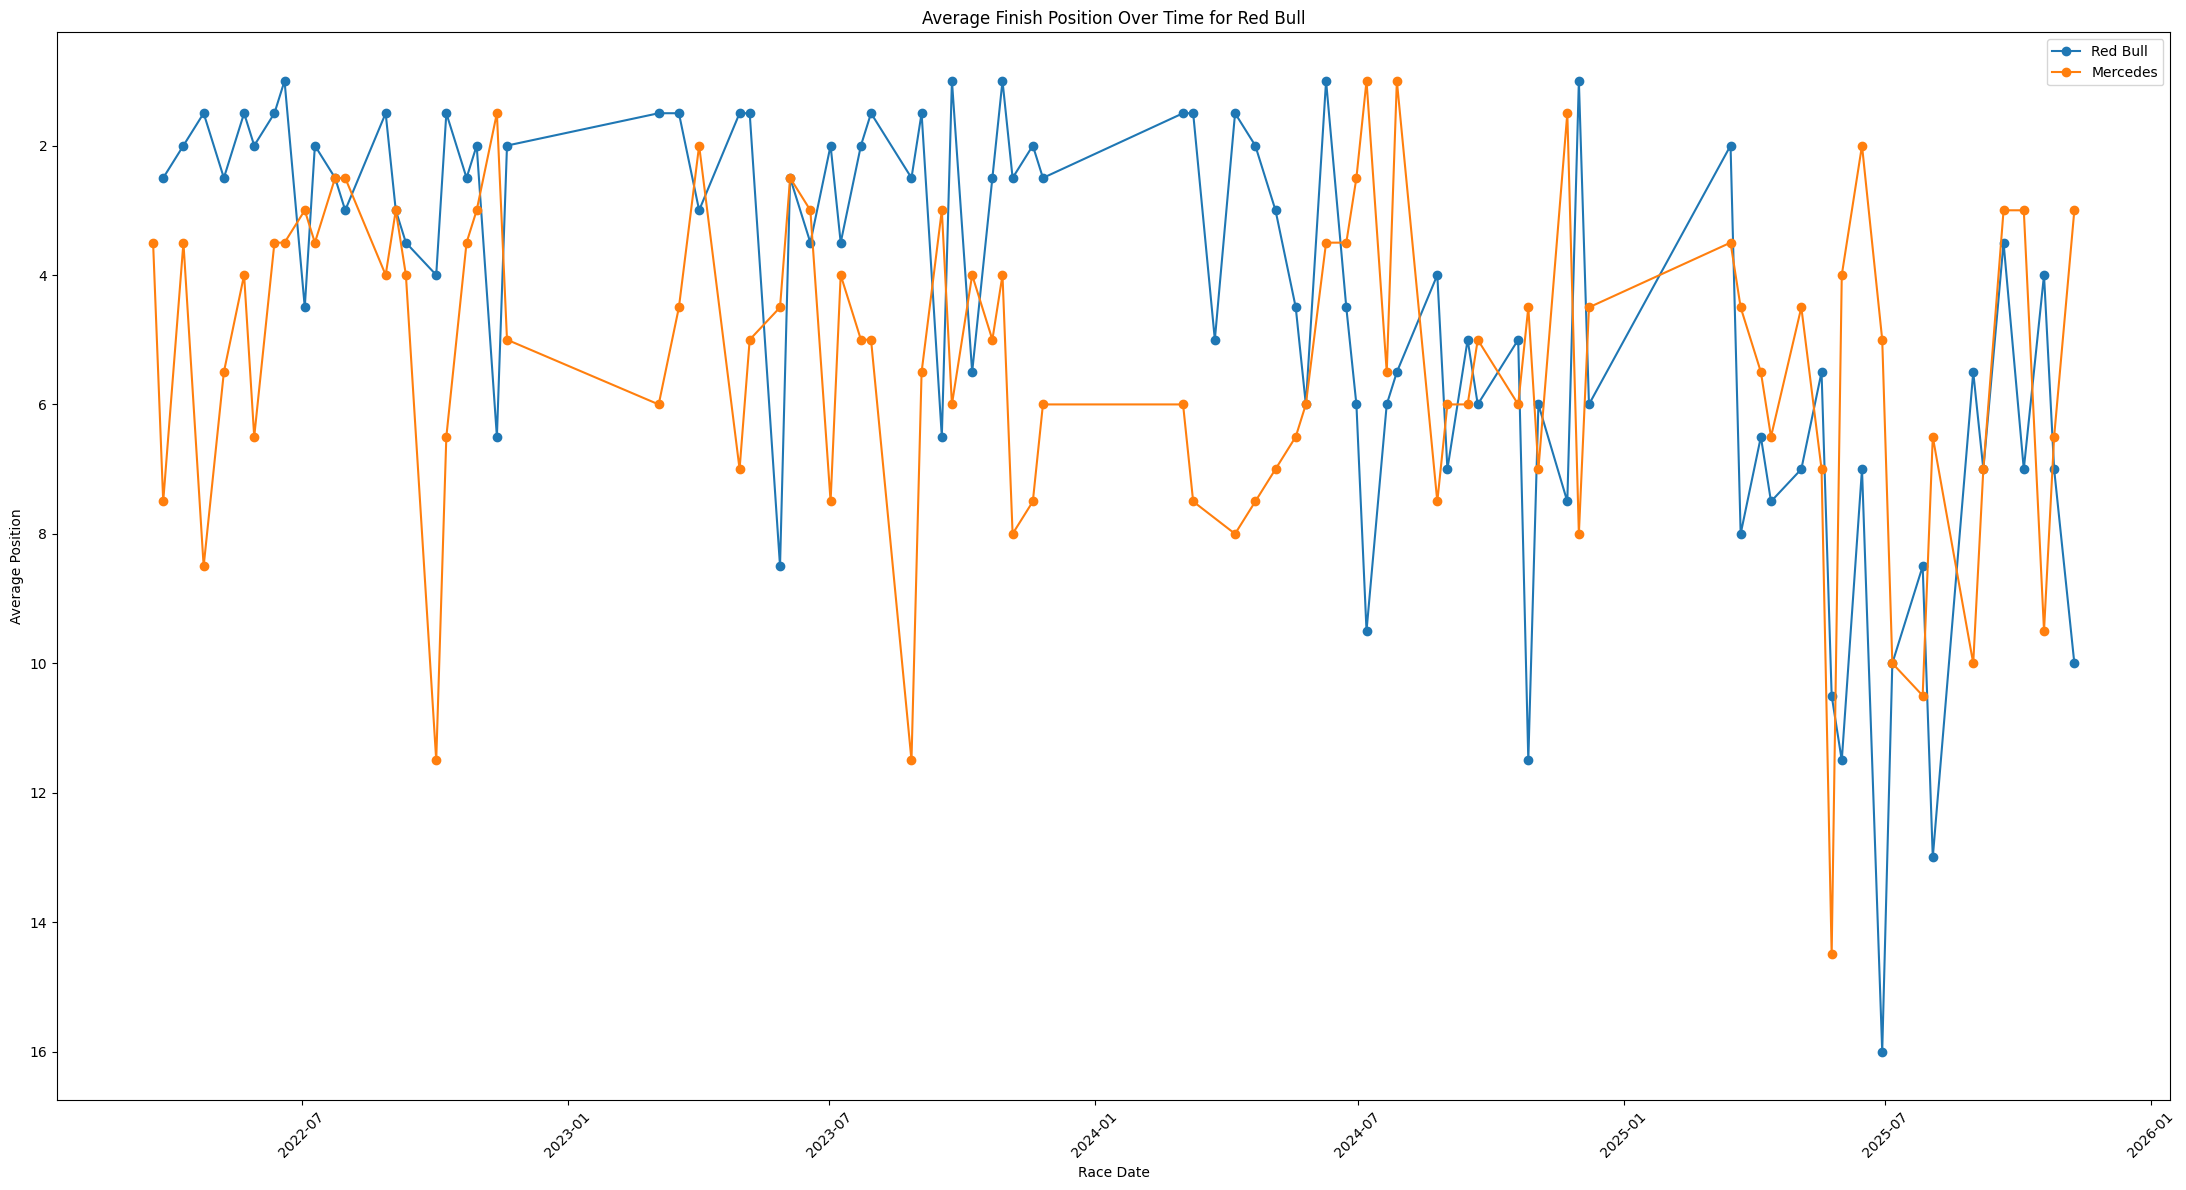

In [51]:
finishes = f1_data[(f1_data['team_dnf'] == 0)&(f1_data['driver_dnf'] == 0)&(f1_data['year']>=2022)]

# Then filter for the two teams
teams_of_interest = ['Red Bull', 'Mercedes']
team_data = finishes[finishes['team'].isin(teams_of_interest)]

# Group by date and calculate average finish position
avg_position_by_date = (
    team_data.groupby(['team', 'date'])['finish']
    .mean()
    .reset_index()
    .sort_values(by='date')
)

# Plot the line graph
plt.figure(figsize=(22, 12))
for team in teams_of_interest:
    team_subset = avg_position_by_date[avg_position_by_date['team'] == team]
    plt.plot(
        team_subset['date'],
        team_subset['finish'],
        marker='o',
        linestyle='-',
        label=team
    )

plt.title('Average Finish Position Over Time for Red Bull')
plt.xlabel('Race Date')
plt.ylabel('Average Position')
plt.gca().invert_yaxis()  # P1 at the top
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


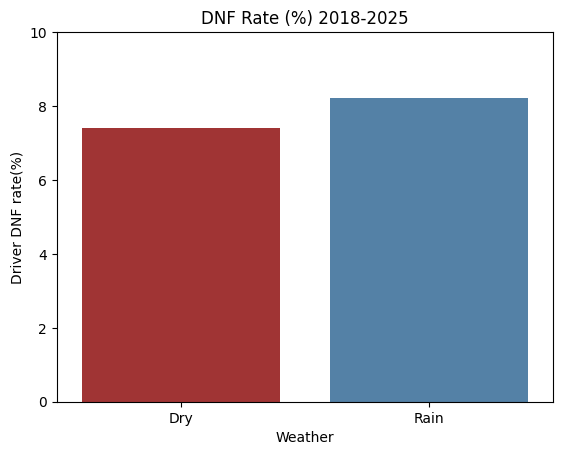

In [52]:
# 1) races per weather type
race_counts = f1_data.groupby('rainfall')['driver_dnf'].count()

# 2) total DNFs per weather type
dnf_counts  = f1_data.groupby('rainfall')['driver_dnf'].sum()

# 3) DNF rate
rate = (dnf_counts / race_counts * 100).reset_index(name='dnf_rate')

# 4) plot

sns.barplot(
    data=rate,
    x='rainfall',
    y='dnf_rate',
    palette={'0': 'firebrick', '1': 'steelblue'}
)
plt.xticks([0, 1], labels=['Dry', 'Rain'])
plt.title('DNF Rate (%) 2018-2025')
plt.xlabel('Weather')
plt.ylabel('Driver DNF rate(%)')
plt.ylim(0, 10)
plt.show()

This graph shows a clear uptick in Driver DNFs when it rains

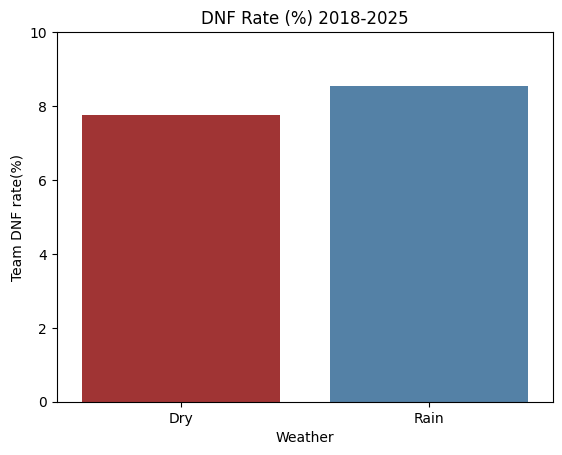

In [53]:
# 1) races per weather type
race_counts = f1_data.groupby('rainfall')['team_dnf'].count()

# 2) total DNFs per weather type
dnf_counts  = f1_data.groupby('rainfall')['team_dnf'].sum()

# 3) DNF rate
rate = (dnf_counts / race_counts * 100).reset_index(name='dnf_rate')

# 4) plot

sns.barplot(
    data=rate,
    x='rainfall',
    y='dnf_rate',
    palette={'0': 'firebrick', '1': 'steelblue'}
)
plt.xticks([0, 1], labels=['Dry', 'Rain'])
plt.title('DNF Rate (%) 2018-2025')
plt.xlabel('Weather')
plt.ylabel('Team DNF rate(%)')
plt.ylim(0, 10)
plt.show()

In [54]:
import statsmodels.api as sm

X = sm.add_constant(f1_data['rainfall'])
y = f1_data['driver_dnf']
rainfall_model = sm.Logit(y, X).fit()
print(rainfall_model.summary())

Optimization terminated successfully.
         Current function value: 0.269351
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             driver_dnf   No. Observations:                 3398
Model:                          Logit   Df Residuals:                     3396
Method:                           MLE   Df Model:                            1
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:               0.0003369
Time:                        15:03:32   Log-Likelihood:                -915.26
converged:                       True   LL-Null:                       -915.56
Covariance Type:            nonrobust   LLR p-value:                    0.4322
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5259      0.076    -33.060      0.000      -2.676      -2.376
rainfall       0.1134      0.

This shows us that while rain has very little effect on DNFs in general, during the rain it's more likely to be a driver error. This makes sense in all semblance becasue F1 cars are designed with rain in mind and safety precautions and driver skills have made is so that rainfall is a non factor in the modern era of racing

/var/folders/3s/qxkngbts3cqdwpx4jy3l2wxr0000gp/T/ipykernel_41686/298208090.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_data['weather'] = weather_data['rainfall'].map({0: 'Dry', 1: 'Rain'})


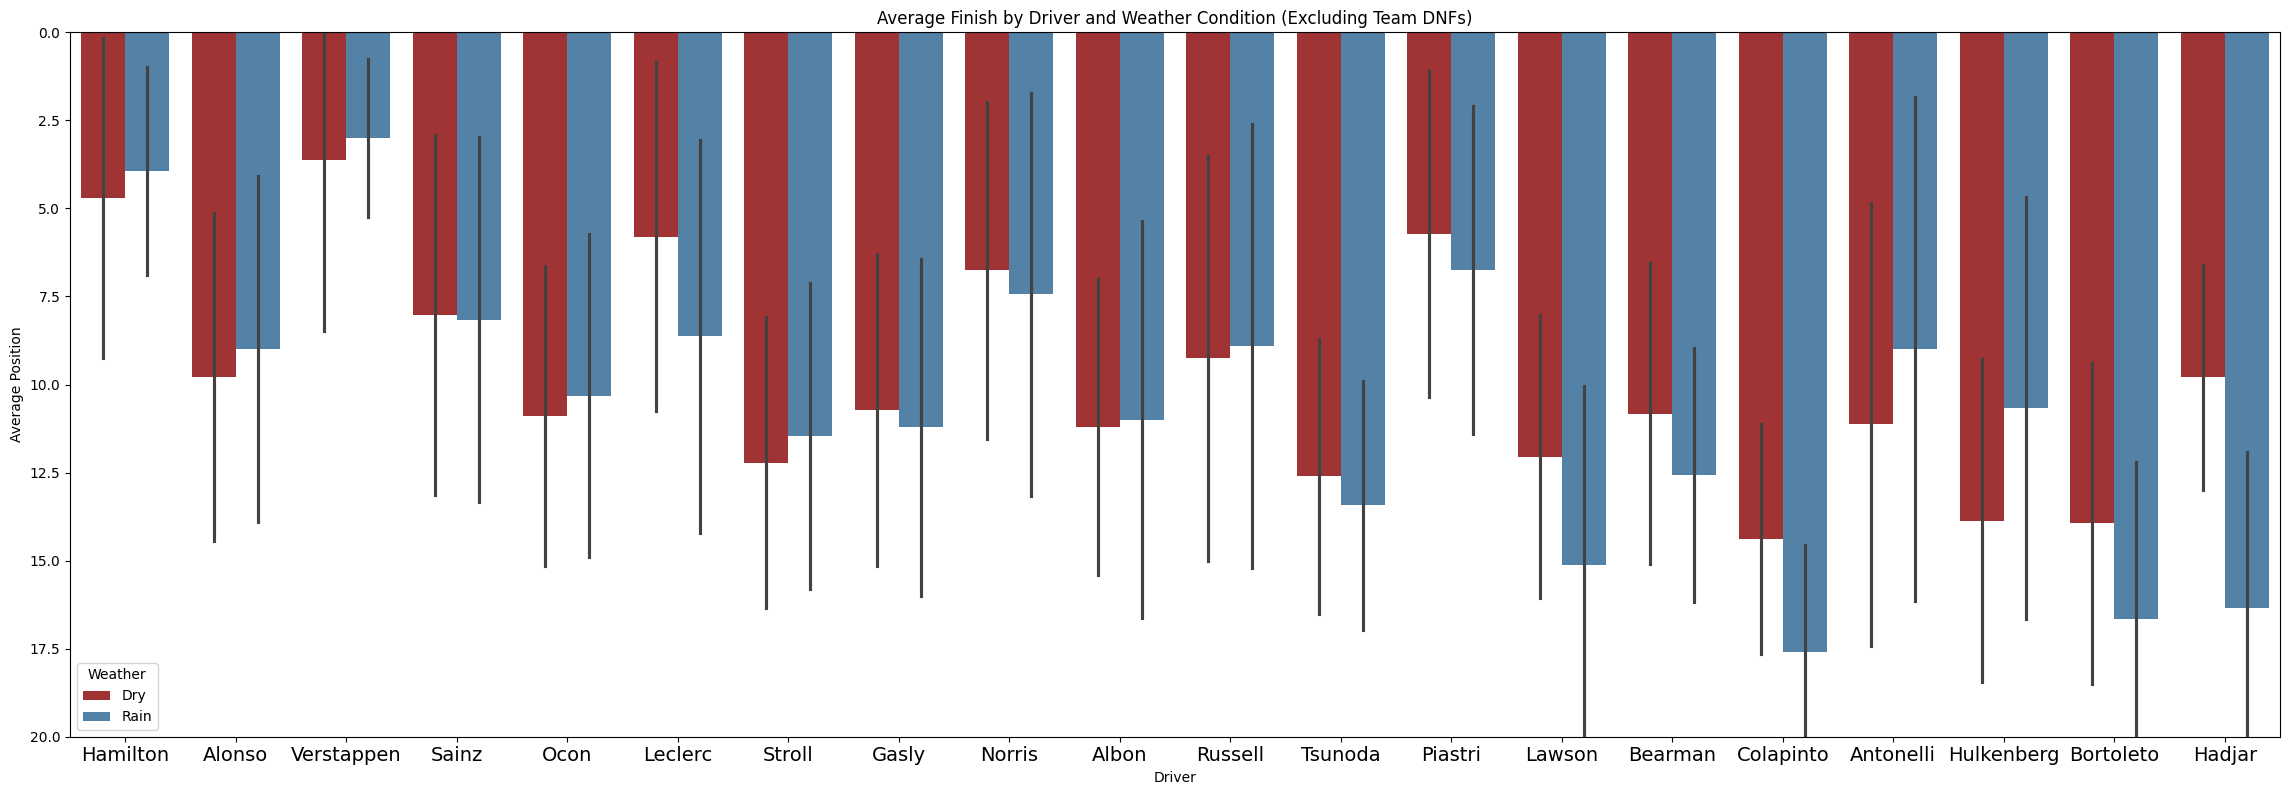

In [55]:
weather_data = f1_data[(f1_data['team_dnf'] == 0) & (f1_data['driver_active']==1)] # Exclude team DNFs because they are not the driver's fault.
weather_data['weather'] = weather_data['rainfall'].map({0: 'Dry', 1: 'Rain'})

plt.figure(figsize=(23, 8))
sns.barplot(
    data=weather_data,
    x='driver',
    y='finish',
    hue='weather',
    hue_order=['Dry', 'Rain'],
    palette={'Dry': 'firebrick', 'Rain': 'steelblue'},
    ci='sd'
)

plt.title('Average Finish by Driver and Weather Condition (Excluding Team DNFs)')
plt.xlabel('Driver')
plt.ylabel('Average Position')
plt.legend(title='Weather')
plt.ylim(0, 20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.xticks(fontsize=14)
plt.show()

In [56]:

## This graph plots average positions for every active driver split by whether it rained or not.
## Not so surprising to see the drivers tend to be worse in the rain.
## However great driver's like Hamilton and Verstappen tend to do better, because other drivers make more mistakes in the rain.
## This is also where Alonso's experience and Antonelli's lack of data points shows clearly.
## All this to say, while rain is not a factor of DNFs, it does affect the position of drivers.


In [57]:
circuit_info = pd.read_csv('./f1_datasets/circuits_df.csv')

In [58]:
f1_data['dnf'] = f1_data['driver_dnf'] + f1_data['team_dnf']
dnf_table = (
    f1_data.groupby(['circuit name'])['dnf']
    .sum()
    .reset_index()
    .rename(columns={'dnf': 'total_dnfs'})
)
dnf_table.sort_values(by='total_dnfs', ascending=False).head(10)

,circuit name,total_dnfs
19,Jeddah Corniche Circuit,36
28,Silverstone Circuit,31
26,Red Bull Ring,30
0,Albert Park Grand Prix Circuit,28
15,Circuit of the Americas,27
8,Baku City Circuit,27
3,Autodromo Nazionale di Monza,26
6,Autódromo José Carlos Pace,26
7,Bahrain International Circuit,24
4,Autódromo Hermanos Rodríguez,22


In [59]:
dnf_table['circuit name'] = dnf_table['circuit name'].str.strip()
circuit_info['circuit name'] = circuit_info['circuit name'].str.strip()

In [60]:
circuit_safety = pd.merge(dnf_table, circuit_info, on='circuit name', how='left')
circuit_safety = circuit_safety[['circuit name', 'total_dnfs', 'Type', 'Turns', 'Grands Prix held']]
circuit_safety.dropna(inplace=True)
circuit_safety

,circuit name,total_dnfs,Type,Turns,Grands Prix held
0,Albert Park Grand Prix Circuit,28,Street circuit,14,28.0
1,Autodromo Enzo e Dino Ferrari,14,Race circuit,19,32.0
2,Autodromo Internazionale del Mugello,8,Race circuit,15,1.0
3,Autodromo Nazionale di Monza,26,Race circuit,11,74.0
4,Autódromo Hermanos Rodríguez,22,Race circuit,17,24.0
6,Autódromo José Carlos Pace,26,Race circuit,15,41.0
7,Bahrain International Circuit,24,Race circuit,15,22.0
8,Baku City Circuit,27,Street circuit,20,8.0
9,Circuit Gilles Villeneuve,18,Street circuit,14,44.0
10,Circuit Park Zandvoort,11,Race circuit,14,34.0


##### The reason why there are so many more DNFs at Austria is because there were 2 races held there in 2020 while many other tracks did not even host one.

##### This prompts us to look at the average rate of dnfs instead of total.

In [61]:
active_circuits = [
    'Bahrain International Circuit', 'Jeddah Corniche Circuit',
    'Albert Park Grand Prix Circuit', 'Suzuka Circuit',
    'Shanghai International Circuit', 'Miami International Autodrome',
    'Autodromo Enzo e Dino Ferrari', 'Circuit de Monaco',
    'Circuit Gilles Villeneuve', 'Circuit de Barcelona-Catalunya',
    'Red Bull Ring', 'Silverstone Circuit', 'Hungaroring',
    'Circuit de Spa-Francorchamps', 'Circuit Park Zandvoort',
    'Autodromo Nazionale di Monza', 'Baku City Circuit',
    'Marina Bay Street Circuit', 'Circuit of the Americas',
    'Autódromo Hermanos Rodríguez', 'Autódromo José Carlos Pace',
    'Las Vegas Strip Street Circuit', 'Losail International Circuit',
    'Yas Marina Circuit'
]

races_per_track = f1_data.groupby('circuit name')['date'].nunique().reset_index()
races_per_track = races_per_track.rename(columns={'date': 'num_races'})
merged = pd.merge(circuit_safety, races_per_track, on='circuit name', how='left')

merged = merged[merged['circuit name'].isin(active_circuits)]

merged['avg_dnfs_per_race'] = merged['total_dnfs'] / merged['num_races']

circuit_safety = merged[['circuit name', 'total_dnfs', 'avg_dnfs_per_race', 'Turns', 'Type', 'Grands Prix held']].sort_values(by='avg_dnfs_per_race', ascending=False)
circuit_safety['type_asint'] = circuit_safety['Type'].apply(lambda x: 1 if x=='Street circuit' else 0)
circuit_safety

,circuit name,total_dnfs,avg_dnfs_per_race,Turns,Type,Grands Prix held,type_asint
17,Jeddah Corniche Circuit,36,7.200000,27,Street circuit,5.0,1
0,Albert Park Grand Prix Circuit,28,4.666667,14,Street circuit,28.0,1
7,Baku City Circuit,27,3.857143,20,Street circuit,8.0,1
14,Circuit of the Americas,27,3.857143,20,Race circuit,12.0,0
5,Autódromo José Carlos Pace,26,3.714286,15,Race circuit,41.0,0
25,Silverstone Circuit,31,3.444444,18,Race circuit,60.0,0
19,Losail International Circuit,10,3.333333,16,Race circuit,3.0,0
3,Autodromo Nazionale di Monza,26,3.250000,11,Race circuit,74.0,0
4,Autódromo Hermanos Rodríguez,22,3.142857,17,Race circuit,24.0,0
8,Circuit Gilles Villeneuve,18,3.000000,14,Street circuit,44.0,1


In [62]:
## Albert Park is usually the first race on the calendar, a lot of rookies making their first appearances, drivers on new teams
## getting acclimated with the car and the team. Other Than that, the circuit is a street circuit, which tends to have more accidents.

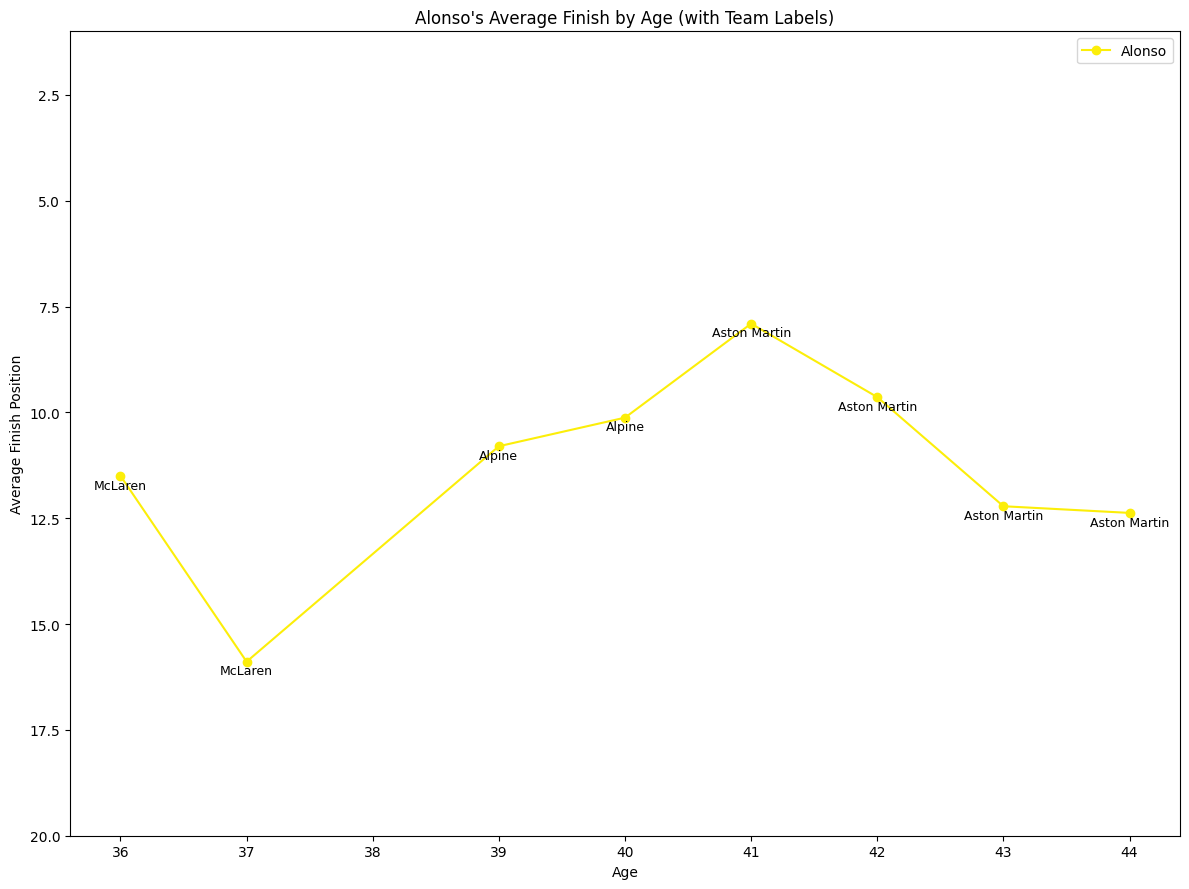

In [63]:
spanish_yellow = '#fcee09'

alonso_data = f1_data[f1_data['driver'] == 'Alonso'].copy()

avg_finish_by_age = (
    alonso_data
    .groupby('age_at_race')
    .agg({
        'finish': 'mean',
        'team': lambda x: x.mode().iloc[0]
    })
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 9))
plt.plot(
    avg_finish_by_age['age_at_race'],
    avg_finish_by_age['finish'],
    color=spanish_yellow,
    marker='o',
    label='Alonso'
)

# Annotate each point with team name
for _, row in avg_finish_by_age.iterrows():
    plt.text(
        row['age_at_race'], row['finish'] + 0.3,
        row['team'],
        fontsize=9,
        ha='center'
    )

plt.xlabel('Age')
plt.ylabel('Average Finish Position')
plt.title("Alonso's Average Finish by Age (with Team Labels)")
plt.legend()
plt.ylim(1, 20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [64]:
import statsmodels.api as sm

# Step 1: Prepare data
df = alonso_data
df['age_sq'] = df['age_at_race'] ** 2

# Step 2: Define X and y
X = df[['age_at_race', 'age_sq']]
X = sm.add_constant(X)
y = df['finish']

# Step 3: Fit OLS model
age_model = sm.OLS(y, X).fit()
print(age_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 finish   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     3.692
Date:                Tue, 02 Dec 2025   Prob (F-statistic):             0.0276
Time:                        15:03:33   Log-Likelihood:                -409.37
No. Observations:                 132   AIC:                             824.7
Df Residuals:                     129   BIC:                             833.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         366.5380    137.123      2.673      

In [65]:
f1_data.columns

Index(['year', 'GP name', 'date', 'start', 'finish', 'team', 'driver', 'dob',
       'circuit name', 'location', 'country', 'driver home', 'team home',
       'driver_dnf', 'team_dnf', 'age_at_race', 'driver_active', 'team_active',
       'avg_air_temp', 'max_air_temp', 'min_air_temp', 'rainfall',
       'avg_humidity', 'max_humidity', 'min_humidity', 'avg_track_temp',
       'max_track_temp', 'min_track_temp', 'dnf'],
      dtype='object')

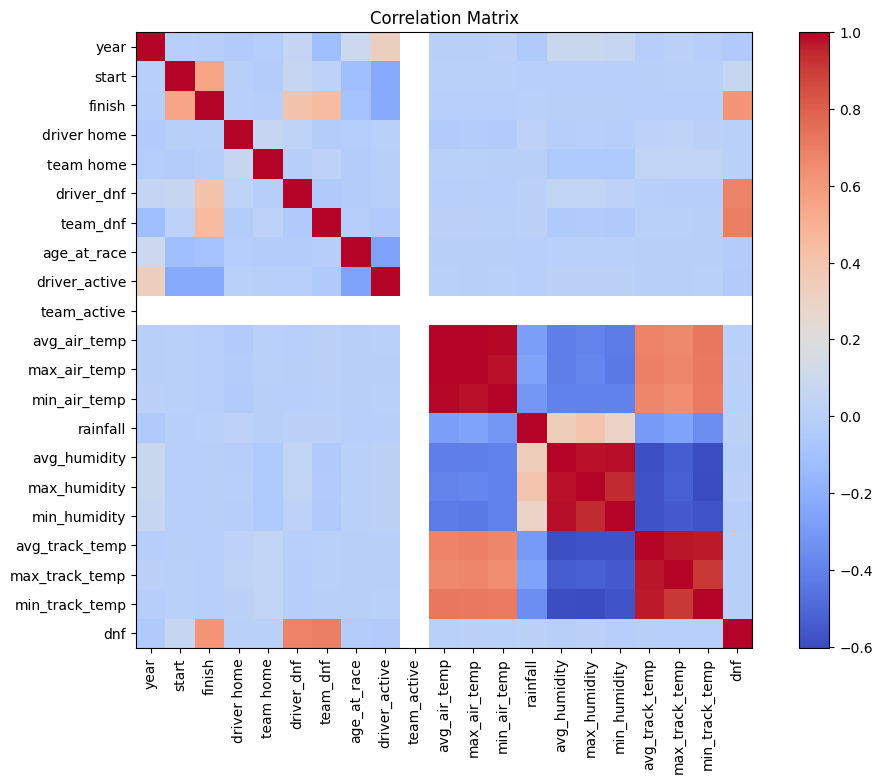

In [66]:
corr = f1_data.corr(numeric_only=True)

# heatmap (optional)
plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [67]:
f1_data.drop(columns='dnf', inplace=True)

In [68]:
f1_data['team_dnf'] = f1_data['team_dnf'].astype(bool)
f1_data['driver_dnf'] = f1_data['driver_dnf'].astype(bool)

In [69]:
cat_cols = f1_data.select_dtypes(include=['object']).columns.tolist()
f1_data_encoded = pd.get_dummies(f1_data, columns=cat_cols, drop_first=True)

In [70]:
cat_cols_ch = f1_data_encoded.select_dtypes(include=['datetime64']).columns.tolist()
cat_cols_ch

['date', 'dob']

In [71]:
from sklearn.model_selection import GroupShuffleSplit

groups = f1_data_encoded['date']   # one race = one group

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(f1_data_encoded, groups=groups))

X_train = f1_data_encoded.iloc[train_idx].drop(columns=['finish','date','dob','driver_dnf','team_dnf'])
y_train = f1_data_encoded.iloc[train_idx]['finish']

X_test  = f1_data_encoded.iloc[test_idx].drop(columns=['finish','date','dob','driver_dnf','team_dnf'])
y_test  = f1_data_encoded.iloc[test_idx]['finish']

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


XGBoost performance on held-out races:
  RMSE: 5.220
  MAE:  4.015
  R²:   0.278
  Spearman rank correlation: 0.559


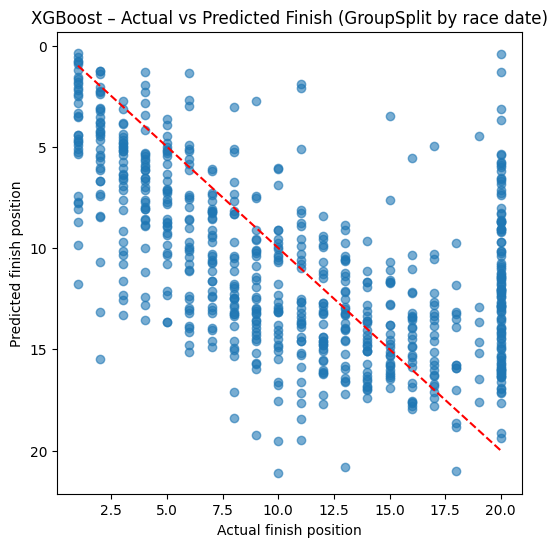

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import numpy as np

# --- Performance metrics ---

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)   # ranking quality

print("XGBoost performance on held-out races:")
print(f"  RMSE: {rmse:.3f}")
print(f"  MAE:  {mae:.3f}")
print(f"  R²:   {r2:.3f}")
print(f"  Spearman rank correlation: {spearman_corr:.3f}")

# --- Optional: scatter plot of actual vs predicted ---

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual finish position")
plt.ylabel("Predicted finish position")
plt.title("XGBoost – Actual vs Predicted Finish (GroupSplit by race date)")
plt.plot([1, 20], [1, 20], 'r--')  # perfect prediction line
plt.gca().invert_yaxis()           # optional: put P1 at the top
plt.show()


In [73]:
import shap

# Create the SHAP explainer for your trained model
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

start             2.612143
driver            1.398948
team              1.139924
GP name           0.488768
age_at_race       0.396473
year              0.213984
max_track_temp    0.162414
avg_air_temp      0.152055
min_track_temp    0.135061
max_air_temp      0.131128
avg_track_temp    0.127142
max_humidity      0.121733
avg_humidity      0.119562
min_air_temp      0.114797
min_humidity      0.099674
country           0.083485
circuit name      0.077544
rainfall          0.039601
driver home       0.034140
team home         0.028357
location          0.007846
Name: group_mean_abs_shap, dtype: float32


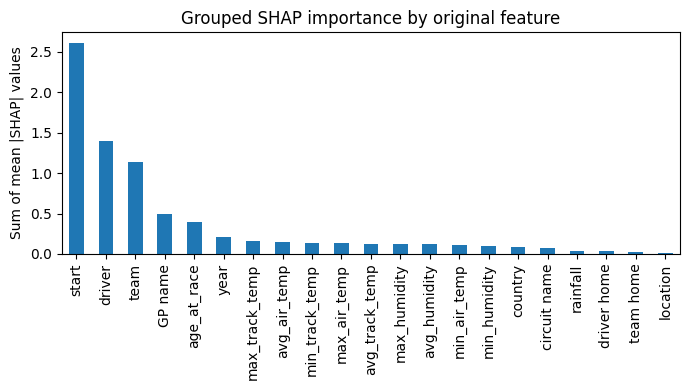

In [74]:
# Columns that belong to each original categorical feature
gp_cols       = [c for c in X_test.columns if c.startswith('GP name_')]
team_cols     = [c for c in X_test.columns if c.startswith('team_')]
driver_cols   = [c for c in X_test.columns if c.startswith('driver_')]
circuit_cols  = [c for c in X_test.columns if c.startswith('circuit name_')]
location_cols = [c for c in X_test.columns if c.startswith('location_')]
country_cols  = [c for c in X_test.columns if c.startswith('country_')]

cat_all = set(gp_cols) | set(team_cols) | set(driver_cols) | \
          set(circuit_cols) | set(location_cols) | set(country_cols)

numeric_individual_cols = [c for c in X_test.columns if c not in cat_all]

group_defs = {
    "GP name": gp_cols,
    "team": team_cols,
    "driver": driver_cols,
    "circuit name": circuit_cols,
    "location": location_cols,
    "country": country_cols
}

for col in numeric_individual_cols:
    group_defs[col] = [col]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=X_test.columns)

# sum importance inside each group
group_importance = pd.Series(
    {g: feat_imp[cols].sum() for g, cols in group_defs.items()},
    name="group_mean_abs_shap"
).sort_values(ascending=False)

print(group_importance)

plt.figure(figsize=(7,4))
group_importance.plot(kind='bar')
plt.ylabel("Sum of mean |SHAP| values")
plt.title("Grouped SHAP importance by original feature")
plt.tight_layout()
plt.show()

In [75]:
f1_data.drop(columns=['avg_air_temp', 'max_air_temp', 'min_air_temp',
       'avg_humidity', 'max_humidity',
       'max_track_temp', 'min_track_temp', 'driver home', 'team home', 'country','location'], inplace=True)

In [76]:
f1_data.columns

Index(['year', 'GP name', 'date', 'start', 'finish', 'team', 'driver', 'dob',
       'circuit name', 'driver_dnf', 'team_dnf', 'age_at_race',
       'driver_active', 'team_active', 'rainfall', 'min_humidity',
       'avg_track_temp'],
      dtype='object')

In [77]:
f1_data['driver_dnf'] = f1_data['driver_dnf'].astype(int)
f1_data['team_dnf']   = f1_data['team_dnf'].astype(int)

f1_data['driver_reliability_rolling10'] = (
    1
    - f1_data.groupby('driver')['driver_dnf']
        .transform(lambda s: s.shift(1).rolling(window=10, min_periods=1).mean())
)

f1_data['team_reliability_rolling10'] = (
    1
    - f1_data.groupby('team')['team_dnf']
        .transform(lambda s: s.shift(1).rolling(window=10, min_periods=1).mean())
)

f1_data['finish_rolling3'] = (
    f1_data.groupby('driver')['finish']
        .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
)

f1_data = f1_data.drop(columns=['driver_dnf', 'team_dnf'])

In [78]:
f1_data.isna().sum()

year                             0
GP name                          0
date                             0
start                            0
finish                           0
team                             0
driver                           0
dob                              0
circuit name                    40
age_at_race                      0
driver_active                    0
team_active                      0
rainfall                         0
min_humidity                     0
avg_track_temp                   0
driver_reliability_rolling10    44
team_reliability_rolling10      10
finish_rolling3                 44
dtype: int64

In [79]:
f1_data = f1_data.fillna(0.5)

In [80]:
cat_cols = f1_data.select_dtypes(include=['object']).columns.tolist()
f1_data_encoded = pd.get_dummies(f1_data, columns=cat_cols, drop_first=True)


In [81]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, ndcg_score
from scipy.stats import spearmanr
from xgboost import XGBRegressor

# =========================
# Helper: NDCG by race (grouped by date)
# =========================
def average_ndcg_by_race(y_true, y_pred, race_ids, k=10):
    """
    Compute average NDCG@k across races (groups), where:
    - y_true: true finishing positions (1 = best)
    - y_pred: predicted finishing positions (lower = better)
    - race_ids: race identifier per row (e.g., date)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    race_ids = np.asarray(race_ids)

    ndcgs = []
    for race in np.unique(race_ids):
        mask = race_ids == race
        yt = y_true[mask]
        yp = y_pred[mask]

        # Need at least 2 cars to have a meaningful ranking
        if yt.shape[0] <= 1:
            continue

        # Convert "position" (1=best) into "relevance" (higher=better)
        max_pos = yt.max()
        rel_true = (max_pos - yt + 1).astype(float)  # P1 gets highest relevance

        # Scores: smaller predicted finish = better → just use negative
        scores = -yp.astype(float)

        k_eff = min(k, len(yt))  # can't rank beyond field size
        ndcg = ndcg_score(
            rel_true.reshape(1, -1),
            scores.reshape(1, -1),
            k=k_eff
        )
        ndcgs.append(ndcg)

    return float(np.mean(ndcgs)) if ndcgs else np.nan

# =========================
# 1) Sort race dates
# =========================
all_dates = np.sort(f1_data_encoded['date'].unique())
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

best_spearman = -np.inf
best_model = None
best_fold_info = None
best_fold_ndcgs = None

print("Time-based CV with XGBoost (Spearman + NDCG per fold):\n")

for fold_idx, (train_date_idx, val_date_idx) in enumerate(tscv.split(all_dates), start=1):
    train_dates = all_dates[train_date_idx]
    val_dates   = all_dates[val_date_idx]

    train_mask = f1_data_encoded['date'].isin(train_dates)
    val_mask   = f1_data_encoded['date'].isin(val_dates)

    train_df = f1_data_encoded.loc[train_mask].copy()
    val_df   = f1_data_encoded.loc[val_mask].copy()

    X_train = train_df.drop(columns=['finish', 'date', 'dob'])
    y_train = train_df['finish']

    X_val = val_df.drop(columns=['finish', 'date', 'dob'])
    y_val = val_df['finish']

    # =========================
    # 2) Train model on this fold
    # =========================
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
    xgb.fit(X_train, y_train)

    # =========================
    # 3) Evaluate on validation races
    # =========================
    y_val_pred = xgb.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    spearman_corr, _ = spearmanr(y_val, y_val_pred)

    # race-wise NDCG
    race_ids = val_df['date'].values
    ndcg3  = average_ndcg_by_race(y_val.values, y_val_pred, race_ids, k=3)
    ndcg10 = average_ndcg_by_race(y_val.values, y_val_pred, race_ids, k=10)
    ndcg20 = average_ndcg_by_race(y_val.values, y_val_pred, race_ids, k=20)

    print(f"Fold {fold_idx}:")
    print(f"  Train races: {train_dates[0]} → {train_dates[-1]}")
    print(f"  Valid races: {val_dates[0]} → {val_dates[-1]}")
    print(f"  RMSE:     {rmse:.3f}")
    print(f"  MAE:      {mae:.3f}")
    print(f"  R²:       {r2:.3f}")
    print(f"  Spearman: {spearman_corr:.3f}")
    print(f"  NDCG@3:   {ndcg3:.3f}")
    print(f"  NDCG@10:  {ndcg10:.3f}")
    print(f"  NDCG@20:  {ndcg20:.3f}\n")

    # =========================
    # 4) Keep model with best Spearman
    # =========================
    if spearman_corr > best_spearman:
        best_spearman = spearman_corr
        best_model = xgb
        best_fold_info = {
            "fold": fold_idx,
            "train_dates": (train_dates[0], train_dates[-1]),
            "val_dates": (val_dates[0], val_dates[-1])
        }
        best_fold_ndcgs = {
            "ndcg3": ndcg3,
            "ndcg10": ndcg10,
            "ndcg20": ndcg20
        }

print("Best model (by validation Spearman):")
print(f"  Fold:        {best_fold_info['fold']}")
print(f"  Train races: {best_fold_info['train_dates'][0]} → {best_fold_info['train_dates'][1]}")
print(f"  Valid races: {best_fold_info['val_dates'][0]} → {best_fold_info['val_dates'][1]}")
print(f"  Best Spearman: {best_spearman:.3f}")
print(f"  Best fold NDCG@3:  {best_fold_ndcgs['ndcg3']:.3f}")
print(f"  Best fold NDCG@10: {best_fold_ndcgs['ndcg10']:.3f}")
print(f"  Best fold NDCG@20: {best_fold_ndcgs['ndcg20']:.3f}")

# `best_model` now has known Spearman + NDCG on its validation races.


Time-based CV with XGBoost (Spearman + NDCG per fold):

Fold 1:
  Train races: 2018-03-25T00:00:00.000000000 → 2019-06-30T00:00:00.000000000
  Valid races: 2019-07-14T00:00:00.000000000 → 2020-12-06T00:00:00.000000000
  RMSE:     5.411
  MAE:      4.215
  R²:       0.229
  Spearman: 0.524
  NDCG@3:   0.839
  NDCG@10:  0.828
  NDCG@20:  0.926

Fold 2:
  Train races: 2018-03-25T00:00:00.000000000 → 2020-12-06T00:00:00.000000000
  Valid races: 2020-12-13T00:00:00.000000000 → 2022-05-08T00:00:00.000000000
  RMSE:     5.174
  MAE:      3.925
  R²:       0.274
  Spearman: 0.565
  NDCG@3:   0.810
  NDCG@10:  0.836
  NDCG@20:  0.922

Fold 3:
  Train races: 2018-03-25T00:00:00.000000000 → 2022-05-08T00:00:00.000000000
  Valid races: 2022-05-22T00:00:00.000000000 → 2023-07-23T00:00:00.000000000
  RMSE:     5.535
  MAE:      4.282
  R²:       0.161
  Spearman: 0.445
  NDCG@3:   0.795
  NDCG@10:  0.806
  NDCG@20:  0.914

Fold 4:
  Train races: 2018-03-25T00:00:00.000000000 → 2023-07-23T00:00:00.00

In [82]:

# =========================
# 1) Global date ordering
# =========================
all_dates = np.sort(f1_data['date'].unique())

# Hold out the *latest* 20% of races as the final test set
test_frac = 0.2
cutoff_test = int(len(all_dates) * (1 - test_frac))

trainval_dates = all_dates[:cutoff_test]   # earlier races → for CV
test_dates    = all_dates[cutoff_test:]    # most recent races → final test

# =========================
# 2) Final test set (latest races)
# =========================
test_idx = f1_data.index[f1_data['date'].isin(test_dates)]
test_df  = f1_data.loc[test_idx].copy()

drop_cols = ['finish', 'date', 'dob']

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_test = test_df['finish']

# Group sizes per race date (for ranking models like LGBMRanker)
test_groups = test_df.groupby('date').size().tolist()

# =========================
# 3) Time-based CV on train+val block
# =========================

# Example: 3-fold expanding-window CV
n_folds = 3
# We split trainval_dates into n_folds+1 blocks: [train ...][val][val][val]
block_size = len(trainval_dates) // (n_folds + 1)

cv_folds = []  # to store (X_train, y_train, train_groups, X_val, y_val, val_groups)

for k in range(1, n_folds + 1):
    # Train uses everything up to train_end
    train_end = block_size * k
    # Validation uses the next block
    val_end = block_size * (k + 1)

    cv_train_dates = trainval_dates[:train_end]
    cv_val_dates   = trainval_dates[train_end:val_end]

    train_idx = f1_data.index[f1_data['date'].isin(cv_train_dates)]
    val_idx   = f1_data.index[f1_data['date'].isin(cv_val_dates)]

    train_df = f1_data.loc[train_idx].copy()
    val_df   = f1_data.loc[val_idx].copy()

    # Build X/y just like before
    X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    y_train = train_df['finish']

    X_val = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])
    y_val = val_df['finish']

    # Group sizes per date for ranking models
    train_groups = train_df.groupby('date').size().tolist()
    val_groups   = val_df.groupby('date').size().tolist()

    cv_folds.append(
        (X_train, y_train, train_groups,
         X_val,   y_val,   val_groups)
    )

from lightgbm import LGBMRanker
from sklearn.metrics import ndcg_score

# ---------- 1. Helper: map finish position -> relevance score ----------
# Smaller finish (1 = winner) should get higher relevance.
max_pos = int(f1_data['finish'].max())

def finish_to_relevance(y):
    """
    y: 1D array-like of finish positions (1 = best).
    Returns relevance scores where higher = better.
    Example: if max_pos = 20, then:
      finish 1 -> rel 20
      finish 2 -> rel 19
      ...
      finish 20 -> rel 1
    """
    y = np.asarray(y)
    return max_pos - y + 1


# ---------- 2. Example param grid for LightGBMRanker ----------
param_grid = [
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_data_in_leaf": 30,
        "feature_fraction": 0.9,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.02,
        "num_leaves": 63,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
    },
]

best_score = -np.inf
best_params = None

cat_cols = ['GP name', 'team', 'driver', 'circuit name']
for col in cat_cols:
    f1_data[col] = f1_data[col].astype('category')


# ---------- 3. Time-based CV loop ----------
for params in param_grid:
    fold_scores = []

    for X_tr, y_tr, g_tr, X_va, y_va, g_va in cv_folds:
        # Convert finish positions to relevance
        y_tr_rel = finish_to_relevance(y_tr)
        y_va_rel = finish_to_relevance(y_va)

        # Define model for this fold
        model = LGBMRanker(
            objective="lambdarank",
            metric="ndcg",
            # LightGBM ranker-specific defaults:
            importance_type="gain",
            verbose=-1,
            **params,
        )

        # Fit model. LightGBM expects 'group' = list of group sizes.
        model.fit(
            X_tr,
            y_tr_rel,
            group=g_tr,
            eval_set=[(X_va, y_va_rel)],
            eval_group=[g_va],
            eval_at=[10],  
        )

        # Predict scores on validation set
        y_va_pred = model.predict(X_va)

        # ----- Compute NDCG@3 manually per race using group sizes -----
        offset = 0
        ndcgs = []
        for group_size in g_va:
            start = offset
            end = offset + group_size

            true_group = y_va_rel[start:end]
            pred_group = y_va_pred[start:end]

            # ndcg_score expects shape (1, n_items)
            ndcg = ndcg_score(
                np.asarray([true_group]),
                np.asarray([pred_group]),
                k=10
            )
            ndcgs.append(ndcg)

            offset = end

        # Mean NDCG@10 over all races in this fold
        fold_scores.append(np.mean(ndcgs))

    mean_score = np.mean(fold_scores)
    print(f"Params: {params}")
    print(f"  Mean CV NDCG@10: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print("\nBest params based on CV NDCG@10:")
print(best_params)
print(f"Best CV NDCG@10: {best_score:.4f}")


# ---------- 4. Refit best model on ALL train+val races ----------
# Rebuild full train+val set from trainval_dates
drop_cols = ['finish', 'date', 'dob']

trainval_idx = f1_data.index[f1_data['date'].isin(trainval_dates)]
trainval_df  = (
    f1_data
    .loc[trainval_idx]
    .sort_values('date')  # ensure races are contiguous in time
    .copy()
)

X_trainval = trainval_df.drop(columns=[c for c in drop_cols if c in trainval_df.columns])
y_trainval = trainval_df['finish']
y_trainval_rel = finish_to_relevance(y_trainval)

# Group sizes for LightGBM on the full train+val block
trainval_groups = trainval_df.groupby('date', sort=False).size().tolist()

lgbm = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    importance_type="gain",
    verbosity=-1,
    **best_params,
)

lgbm.fit(
    X_trainval,
    y_trainval_rel,
    group=trainval_groups,
)


# ---------- 5. Final evaluation on time-based test set ----------
# Transform test y to relevance
# 1. Convert test finishes to relevance + get predicted scores
y_test_rel = finish_to_relevance(y_test)        # higher = more relevant (better finish)
y_test_pred = lgbm.predict(X_test)        # model scores

# 2. Compute NDCG@k per race, then average over all races
def ndcg_at_k_for_test(k_list=(3, 10, 20)):
    results = {k: [] for k in k_list}
    offset = 0

    for group_size in test_groups:
        start = offset
        end = offset + group_size

        true_group = y_test_rel[start:end]
        pred_group = y_test_pred[start:end]

        # shape (1, n_items) for sklearn
        true_group = np.asarray([true_group])
        pred_group = np.asarray([pred_group])

        for k in k_list:
            k_eff = min(k, group_size)  # in case fewer drivers than k
            ndcg = ndcg_score(true_group, pred_group, k=k_eff)
            results[k].append(ndcg)

        offset = end

    # mean over races
    mean_results = {k: float(np.mean(v)) for k, v in results.items()}
    return mean_results

ndcg_scores = ndcg_at_k_for_test(k_list=[3, 10, 20])

print("Test NDCG scores (mean over races):")
print(f"  NDCG@3  = {ndcg_scores[3]:.4f}")
print(f"  NDCG@10 = {ndcg_scores[10]:.4f}")
print(f"  NDCG@20 = {ndcg_scores[20]:.4f}")

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: GP name: object, team: object, driver: object, circuit name: object

In [ ]:

# 1. Make prediction DataFrame for the test set
pred_df = test_df.copy()
pred_df['pred_score'] = lgbm.predict(X_test)

# Convert scores -> predicted finishing position (1 = best)
pred_df['pred_finish'] = (
    pred_df
    .groupby('date')['pred_score']
    .rank(ascending=False, method='first')
    .astype(int)
)

# 2. Spearman correlation per race
race_spearman = []

for race_date, g in pred_df.groupby('date'):
    true_finish = g['finish'].values          # 1..20 true order
    pred_finish = g['pred_finish'].values     # 1..20 predicted order

    corr, _ = spearmanr(true_finish, pred_finish)
    race_spearman.append(corr)

# 3. Aggregate over races
race_spearman = np.array(race_spearman)

print(f"Mean Spearman over test races:   {np.nanmean(race_spearman):.4f}")
print(f"Median Spearman over test races: {np.nanmedian(race_spearman):.4f}")
print(f"Min / Max Spearman:              {np.nanmin(race_spearman):.4f} / {np.nanmax(race_spearman):.4f}")


Mean Spearman over test races:   0.6788
Median Spearman over test races: 0.7126
Min / Max Spearman:              0.1220 / 0.9218


In [ ]:
pred_df = test_df.copy()
pred_df['pred_score'] = lgbm.predict(X_test)

pred_df['pred_finish'] = (
    pred_df
    .groupby('date')['pred_score']
    .rank(ascending=False, method='first')
    .astype(int)
)

some_race_date = pred_df['date'].iloc[-1] # -1 for the latest race in the test set

print("\nExample race predictions:")
display_cols = ['date', 'driver', 'team', 'start', 'finish', 'pred_finish', 'pred_score']
(
    pred_df[pred_df['date'] == some_race_date][display_cols]
    .sort_values('pred_finish')   
    .head(20)                     
)


Example race predictions:


,date,driver,team,start,finish,pred_finish,pred_score
3439,2025-11-09,Norris,McLaren,1,1,1,1.167744
3459,2025-11-09,Leclerc,Ferrari,3,20,2,-0.686512
3440,2025-11-09,Antonelli,Mercedes,2,2,3,-0.731731
3444,2025-11-09,Piastri,McLaren,4,5,4,-0.901560
3441,2025-11-09,Verstappen,Red Bull,19,3,5,-1.020520
3443,2025-11-09,Russell,Mercedes,6,4,6,-1.867589
3457,2025-11-09,Hamilton,Ferrari,13,20,7,-2.085116
3447,2025-11-09,Hadjar,RB F1 Team,5,8,8,-3.110693
3445,2025-11-09,Bearman,Haas F1 Team,8,6,9,-3.855487
3446,2025-11-09,Lawson,RB F1 Team,7,7,10,-3.921849


In [ ]:
# Columns you don't want as features
drop_cols = ['finish','date','dob']  # add others you excluded (e.g. 'raceId', 'driverId' if needed)

# Use all completed races
train_df = f1_data.copy()

X_all = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
y_all = train_df['finish']
max_pos = int(y_all.max())
y_all_rel = max_pos - y_all + 1

# Group sizes per race for ranking
group_all = train_df.groupby('date').size().tolist()  # or whatever race ID col you use

# Refit existing lgbm ranker
lgbm.fit(X_all, y_all_rel, group=group_all)




,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.02
,n_estimators,700
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
Qatar2025 = pd.read_csv('./f1_datasets/Qatar data.csv')

In [ ]:
# Desired starting grid P1 → P20 by LAST NAME
grid_last = [
    "Piastri",      # 1
    "Norris",       # 2
    "Verstappen",   # 3
    "Russell",      # 4
    "Antonelli",    # 5
    "Hadjar",       # 6
    "Sainz",        # 7
    "Alonso",       # 8
    "Gasly",        # 9
    "Leclerc",      # 10
    "Hulkenberg",   # 11
    "Lawson",       # 12
    "Bearman",      # 13
    "Albon",        # 14
    "Tsunoda",      # 15
    "Ocon",         # 16
    "Hamilton",     # 17
    "Stroll",       # 18
    "Bortoleto",    # 19
    "Colapinto"     # 20
]

# driver (last name) -> starting position
start_map = {lname: pos for pos, lname in enumerate(grid_last, start=1)}

# overwrite 'start' in Qatar2025 using last names
Qatar2025['start'] = Qatar2025['driver'].map(start_map)

# make sure 'start' is int, then sort descending
Qatar2025['start'] = Qatar2025['start'].astype(int)

Qatar2025 = Qatar2025.sort_values('start', ascending=True).reset_index(drop=True)

# quick check
print(Qatar2025[['start', 'driver']])


    start      driver
0       1     Piastri
1       2      Norris
2       3  Verstappen
3       4     Russell
4       5   Antonelli
5       6      Hadjar
6       7       Sainz
7       8      Alonso
8       9       Gasly
9      10     Leclerc
10     11  Hulkenberg
11     12      Lawson
12     13     Bearman
13     14       Albon
14     15     Tsunoda
15     16        Ocon
16     17    Hamilton
17     18      Stroll
18     19   Bortoleto
19     20   Colapinto


In [ ]:
team_map = (
    f1_data
    .sort_values('date')        
    .dropna(subset=['team'])       
    .drop_duplicates(subset='driver', keep='last')  
    .set_index('driver')['team']      
)

Qatar2025['team'] = Qatar2025['driver'].map(team_map)


In [ ]:
Qatar2025['date'] = pd.to_datetime(Qatar2025['date'])
Qatar2025['dob']  = pd.to_datetime(Qatar2025['dob'])

Qatar2025['age_at_race'] = ((Qatar2025['date'] - Qatar2025['dob']).dt.days / 365.25).astype(int)

In [ ]:
import pandas as pd
import numpy as np

# Make sure dates are datetime
f1_data['date']    = pd.to_datetime(f1_data['date'])
Qatar2025['date']  = pd.to_datetime(Qatar2025['date'])

last_race = (
    f1_data
    .sort_values('date')  # oldest → newest
    .dropna(subset=['driver_reliability_rolling10', 'team_reliability_rolling10'])
    .drop_duplicates(subset='driver', keep='last')  # keep most recent row per driver
)

driver_rel_map = last_race.set_index('driver')['driver_reliability_rolling10']
team_rel_map   = last_race.set_index('driver')['team_reliability_rolling10']

Qatar2025['driver_reliability_rolling10'] = Qatar2025['driver'].map(driver_rel_map)
Qatar2025['team_reliability_rolling10']   = Qatar2025['driver'].map(team_rel_map)

qatar_date = Qatar2025['date'].iloc[0]

# Only use races BEFORE Qatar 2025 (no leakage)
hist = f1_data[f1_data['date'] < qatar_date].copy()

def finish_roll3_for_driver(drv: str) -> float:
    drv_hist = (
        hist[hist['driver'] == drv]
        .sort_values('date')   
        .tail(3)             
    )
    if drv_hist.empty:
        return 0.5
    return drv_hist['finish'].mean()

Qatar2025['finish_rolling3'] = Qatar2025['driver'].apply(finish_roll3_for_driver)


In [ ]:
common_cols = [c for c in f1_data.columns if c in Qatar2025.columns]
Qatar2025 = Qatar2025[common_cols]

In [ ]:
Qatar2025 = Qatar2025.rename(
    columns={
         'GP name': 'GP_name',
        'circuit name': 'circuit_name'
    }
 )

In [ ]:
Qatar2025.head()

,year,GP_name,date,start,finish,team,driver,dob,circuit_name,age_at_race,driver_active,team_active,rainfall,min_humidity,avg_track_temp,driver_reliability_rolling10,team_reliability_rolling10,finish_rolling3
0,2025,Qatar Grand Prix,2025-11-30,1,NaN,McLaren,Piastri,2001-04-06,Losail International Circuit,24,1,1,0,53,24,0.9,1.0,5.000000
1,2025,Qatar Grand Prix,2025-12-02,2,NaN,McLaren,Norris,1999-11-13,Losail International Circuit,26,1,1,0,53,24,0.9,1.0,1.333333
2,2025,Qatar Grand Prix,2025-12-05,3,NaN,Red Bull,Verstappen,1972-03-04,Losail International Circuit,53,1,1,0,53,24,0.9,1.0,2.333333
3,2025,Qatar Grand Prix,2025-12-01,4,NaN,Mercedes,Russell,1998-02-15,Losail International Circuit,27,1,1,0,53,24,1.0,1.0,5.666667
4,2025,Qatar Grand Prix,2025-12-06,5,NaN,Mercedes,Antonelli,2006-08-25,Losail International Circuit,19,1,1,0,53,24,0.8,1.0,7.000000


In [ ]:
# Feature Columns for the model

drop_cols = ['finish', 'date', 'dob']

feature_cols = [c for c in lgbm.feature_name_ if c not in drop_cols]

Qatar2025_features = Qatar2025[feature_cols]

print("Model expects:", lgbm.n_features_in_)
print("Qatar2025_features has:", Qatar2025_features.shape[1])

print("Model feature names:", lgbm.feature_name_)
print("Your feature_cols:", feature_cols)



Model expects: 15
Qatar2025_features has: 15
Model feature names: ['year', 'GP_name', 'start', 'team', 'driver', 'circuit_name', 'age_at_race', 'driver_active', 'team_active', 'rainfall', 'min_humidity', 'avg_track_temp', 'driver_reliability_rolling10', 'team_reliability_rolling10', 'finish_rolling3']
Your feature_cols: ['year', 'GP_name', 'start', 'team', 'driver', 'circuit_name', 'age_at_race', 'driver_active', 'team_active', 'rainfall', 'min_humidity', 'avg_track_temp', 'driver_reliability_rolling10', 'team_reliability_rolling10', 'finish_rolling3']


In [ ]:
# Change the dtypes of all categorical columns to 'category' for the dtypes to match.

cat_cols = ['GP_name', 'team', 'driver', 'circuit_name']

for col in cat_cols:
    Qatar2025[col] = Qatar2025[col].astype('category')

print(Qatar2025[feature_cols].dtypes)


year                               int64
GP_name                         category
start                              int64
team                            category
driver                          category
circuit_name                    category
age_at_race                        int64
driver_active                      int64
team_active                        int64
rainfall                           int64
min_humidity                       int64
avg_track_temp                     int64
driver_reliability_rolling10     float64
team_reliability_rolling10       float64
finish_rolling3                  float64
dtype: object


In [ ]:
Qatar2025_features = Qatar2025[feature_cols]
new_pred = lgbm.predict(Qatar2025_features)
Qatar2025['pred_score'] = new_pred

Qatar2025['pred_finish'] = (Qatar2025['pred_score'].rank(ascending=False, method='first').astype(int))

Qatar2025[['start', 'pred_finish', 'driver', 'pred_score']].sort_values('pred_finish').reset_index(drop=True)

,start,pred_finish,driver,pred_score
0,1,1,Piastri,2.111016
1,3,2,Verstappen,0.565741
2,2,3,Norris,0.396561
3,4,4,Russell,-1.389740
4,5,5,Antonelli,-2.764597
5,10,6,Leclerc,-3.030944
6,9,7,Gasly,-3.350712
7,7,8,Sainz,-3.585568
8,6,9,Hadjar,-3.989677
9,8,10,Alonso,-4.083516


In [84]:
f1_data.shape

(3398, 18)